# DEM para Santiago de Chile
Descarga el Modelo Digital de Elevación (DEM) para Santiago usando **Copernicus DEM 30m** vía `py-dem-stitcher`. Sin login requerido.

**Bounding box:** `-71.5, -33.75, -70.3, -33.1` (lon_min, lat_min, lon_max, lat_max)

## 1. Instalación de dependencias

## 2. Descarga del DEM (Copernicus GLO-30)

In [2]:
from dem_stitcher import stitch_dem
import numpy as np
import rasterio

# Bounding box: [lon_min, lat_min, lon_max, lat_max]
BOUNDS = [-71.5, -33.75, -70.3, -33.1]
OUTPUT_FILE = "nasadem_santiago.tif"

print("Descargando DEM Copernicus 30m para Santiago...")
arr, profile = stitch_dem(
    BOUNDS,
    dem_name='glo_30',          # Copernicus GLO-30: global, sin login
    dst_ellipsoidal_height=False,
    dst_area_or_point='Point'
)

# Guardar como GeoTIFF
profile.update(dtype='float32', compress='lzw')
with rasterio.open(OUTPUT_FILE, 'w', **profile) as dst:
    dst.write(arr.astype('float32'), 1)

print(f"✅ Archivo guardado: {OUTPUT_FILE}")

Descargando DEM Copernicus 30m para Santiago...


Reading tile metadata:   0%|          | 0/2 [00:00<?, ?it/s]/Users/calipsotornasol/Documents/geodata/.venv/lib/python3.11/site-packages/dem_stitcher/rio_window.py:144: RuntimeWarning: Requesting extent beyond raster bounds of [-72.00013888888888, -33.99986111111111, -71.00013888888888, -32.99986111111111]. Shrinking bounds in raster crs to (-71.5, -33.75, -71.00013888888888, -33.1).
  warn(
Reading tile imagery: 100%|██████████| 2/2 [00:06<00:00,  3.30s/it]


✅ Archivo guardado: nasadem_santiago.tif


## 3. Verificar el archivo

In [3]:
import rasterio
import numpy as np

with rasterio.open(OUTPUT_FILE) as r:
    print("=== Info del raster ===")
    print(f"CRS        : {r.crs}")
    print(f"Resolución : ~{r.res[0]*111320:.0f} m")
    print(f"Dimensiones: {r.width} x {r.height} px")
    print(f"Bounds     : {r.bounds}")

    data = r.read(1).astype(float)
    if r.nodata:
        data[data == r.nodata] = np.nan

    print(f"\nElevación mínima : {np.nanmin(data):.0f} m")
    print(f"Elevación máxima : {np.nanmax(data):.0f} m")
    print(f"Elevación media  : {np.nanmean(data):.0f} m")

=== Info del raster ===
CRS        : EPSG:4326
Resolución : ~31 m
Dimensiones: 4321 x 2341 px
Bounds     : BoundingBox(left=-71.50013888888888, bottom=-33.75013888888889, right=-70.29986111111111, top=-33.09986111111111)

Elevación mínima : 52 m
Elevación máxima : 4040 m
Elevación media  : 810 m


## 4. Visualización

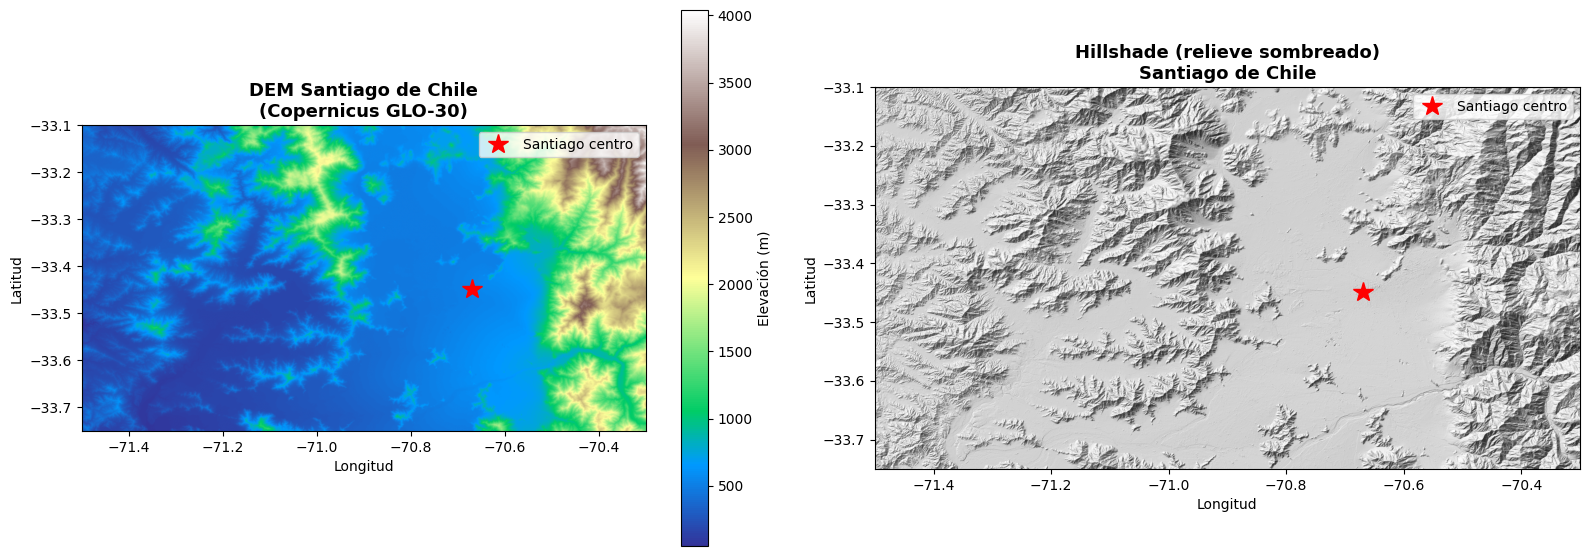

✅ Visualización guardada como santiago_dem_preview.png


In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import rasterio
import numpy as np

with rasterio.open(OUTPUT_FILE) as r:
    data = r.read(1).astype(float)
    bounds = r.bounds
    if r.nodata:
        data[data == r.nodata] = np.nan

ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: elevación
ax1 = axes[0]
im = ax1.imshow(data, cmap='terrain', extent=ext, origin='upper')
plt.colorbar(im, ax=ax1, label='Elevación (m)', shrink=0.8)
ax1.plot(-70.6693, -33.4489, 'r*', markersize=15, label='Santiago centro')
ax1.set_title('DEM Santiago de Chile\n(Copernicus GLO-30)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Longitud')
ax1.set_ylabel('Latitud')
ax1.legend()

# Panel derecho: hillshade
ax2 = axes[1]
ls = LightSource(azdeg=315, altdeg=45)
hs = ls.hillshade(np.where(np.isnan(data), 0, data), vert_exag=3, dx=30, dy=30)
ax2.imshow(hs, cmap='gray', extent=ext, origin='upper')
ax2.plot(-70.6693, -33.4489, 'r*', markersize=15, label='Santiago centro')
ax2.set_title('Hillshade (relieve sombreado)\nSantiago de Chile', fontsize=13, fontweight='bold')
ax2.set_xlabel('Longitud')
ax2.set_ylabel('Latitud')
ax2.legend()

plt.tight_layout()
plt.savefig('santiago_dem_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualización guardada como santiago_dem_preview.png")

## 5. (Opcional) Reproyectar a UTM 19S

In [5]:
from rasterio.warp import calculate_default_transform, reproject, Resampling
import rasterio

OUTPUT_UTM = "nasadem_santiago_utm19s.tif"
DST_CRS = 'EPSG:32719'  # UTM zona 19S

with rasterio.open(OUTPUT_FILE) as src:
    transform, width, height = calculate_default_transform(
        src.crs, DST_CRS, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({'crs': DST_CRS, 'transform': transform,
                   'width': width, 'height': height})

    with rasterio.open(OUTPUT_UTM, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=DST_CRS,
            resampling=Resampling.bilinear
        )

with rasterio.open(OUTPUT_UTM) as r:
    print(f"✅ Guardado: {OUTPUT_UTM}")
    print(f"   CRS: {r.crs}")
    print(f"   Resolución: ~{r.res[0]:.0f} x {r.res[1]:.0f} metros")

✅ Guardado: nasadem_santiago_utm19s.tif
   CRS: EPSG:32719
   Resolución: ~27 x 27 metros


## Archivos generados

| Archivo | Descripción |
|---|---|
| `nasadem_santiago.tif` | DEM en WGS84 (EPSG:4326) |
| `nasadem_santiago_utm19s.tif` | DEM en UTM 19S — coordenadas en metros |
| `santiago_dem_preview.png` | Visualización del terreno y hillshade |